In [1]:
# ============================================================
# 🧩 Shell 1 — YOLOv8 Model Loader (Stable Base)
# ============================================================
import os
from ultralytics import YOLO
import torch

# --- Path to saved model ---
MODEL_PATH = r"C:\Project\Smart Parking\Model\best.pt"

# --- Safety Checks ---
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"❌ Model not found at: {MODEL_PATH}")

# --- Device Selection ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🔹 Using device: {DEVICE}")

# --- Load Model ---
model = YOLO(MODEL_PATH)

# --- Verify model metadata ---
try:
    class_names = model.names
    num_classes = len(class_names)
    print(f"✅ YOLO model loaded successfully on {DEVICE.upper()}")
    print(f"📦 Classes Detected ({num_classes}): {list(class_names.values())}")
except Exception:
    print("⚠️ Model loaded, but class names could not be read (check model training metadata).")

# --- Ready for downstream tasks (forecasting / explainability) ---


🔹 Using device: cuda
✅ YOLO model loaded successfully on CUDA
📦 Classes Detected (2): ['occupied', 'free']


In [2]:
# ============================================================
# 🧩 Shell 2 — Dataset Path Configuration (Local Use Only)
# ============================================================
import os
LABEL_DIR   = r"C:\Project\Smart Parking\LocalMachine\Yolo\labels"                 # or "labels" if already extracted
IMAGE_DIR   = r"C:\Project\Smart Parking\LocalMachine\Yolo\dataset\FULL_IMAGE_1000x750"   # main folder with SUNNY/RAINY/OVERCAST
OUTPUT_DIR  = r"C:\Project\Smart Parking\LocalMachine\Yolo"                     # for detections.csv, forecasts, etc.
MODEL_PATH  = r"C:\Project\Smart Parking\LocalMachine\Yolo\Model\best.pt"               # YOLO weights
VIDEOS_DIR  = r"C:\Project\Smart Parking\Test Videos"                  # folder containing 4s and 39s videos

# --- Safety checks ---
for p in [LABEL_DIR, IMAGE_DIR, MODEL_PATH]:
    if not os.path.exists(p):
        print(f"⚠️  Path missing or incorrect: {p}")

# --- Create output folder if missing ---
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Summary ---
print("✅ Directory configuration set:")
print(f"🏷  Labels:     {LABEL_DIR}")
print(f"🖼  Images:     {IMAGE_DIR}")
print(f"🎥  Test Videos:{VIDEOS_DIR}")
print(f"💾 Output Dir: {OUTPUT_DIR}")
print(f"🧠 Model Path: {MODEL_PATH}")

# --- Ready for use by YOLO + LSTM + XAI pipelines ---


✅ Directory configuration set:
🏷  Labels:     C:\Project\Smart Parking\LocalMachine\Yolo\labels
🖼  Images:     C:\Project\Smart Parking\LocalMachine\Yolo\dataset\FULL_IMAGE_1000x750
🎥  Test Videos:C:\Project\Smart Parking\Test Videos
💾 Output Dir: C:\Project\Smart Parking\LocalMachine\Yolo
🧠 Model Path: C:\Project\Smart Parking\LocalMachine\Yolo\Model\best.pt


In [3]:
# ============================================================
# 🧩 Shell 3 (Revised) — Universal Slot Occupancy Builder
# ============================================================
import os, glob
from tqdm import tqdm
import pandas as pd
from datetime import datetime
from ultralytics import YOLO

# --- Core paths (match your structure) ---
YOLO_MODEL = r"C:\Project\Smart Parking\LocalMachine\Yolo\Model\best.pt"
IMAGE_ROOT = r"C:\Project\Smart Parking\LocalMachine\Yolo\dataset\FULL_IMAGE_1000x750"
OUTPUT_PATH = r"C:\Project\Smart Parking\LocalMachine\Yolo\detections.csv"
SLOT_META_DIR = r"C:\Project\Smart Parking\LocalMachine\Yolo\dataset"

# --- Parameters ---
IOU_THRESH = 0.30
CONF_THRESH = 0.30
ORIG_W, ORIG_H = 2592, 1944
IMG_W, IMG_H = 1000, 750

# ============================================================
# 🧠 Load YOLO model
# ============================================================
if not os.path.exists(YOLO_MODEL):
    raise FileNotFoundError(f"❌ Model not found: {YOLO_MODEL}")

model = YOLO(YOLO_MODEL)
device = "cuda" if model.device.type == "cuda" else "cpu"
print(f"✅ YOLOv8 model loaded on {device}")

# ============================================================
# 🧩 IoU helper
# ============================================================
def iou(a, b):
    xa, ya = max(a[0], b[0]), max(a[1], b[1])
    xb, yb = min(a[2], b[2]), min(a[3], b[3])
    iw, ih = max(0, xb - xa), max(0, yb - ya)
    inter = iw * ih
    areaA = (a[2]-a[0]) * (a[3]-a[1])
    areaB = (b[2]-b[0]) * (b[3]-b[1])
    union = areaA + areaB - inter + 1e-9
    return inter / union if union > 0 else 0.0

# ============================================================
# 🧩 Function to scale camera slot metadata
# ============================================================
def load_scaled_slots(camera_csv):
    slots_df = pd.read_csv(camera_csv)
    sx, sy = IMG_W / ORIG_W, IMG_H / ORIG_H
    slots_df["x1"] = (slots_df["X"] * sx).astype(int)
    slots_df["y1"] = (slots_df["Y"] * sy).astype(int)
    slots_df["x2"] = ((slots_df["X"] + slots_df["W"]) * sx).astype(int)
    slots_df["y2"] = ((slots_df["Y"] + slots_df["H"]) * sy).astype(int)
    return slots_df

# ============================================================
# 📸 Iterate over all weathers → dates → cameras
# ============================================================
rows = []
weathers = sorted([w for w in os.listdir(IMAGE_ROOT) if os.path.isdir(os.path.join(IMAGE_ROOT, w))])
print(f"🌦 Found weathers: {weathers}")

for weather in weathers:
    weather_path = os.path.join(IMAGE_ROOT, weather)
    date_folders = sorted([d for d in os.listdir(weather_path) if os.path.isdir(os.path.join(weather_path, d))])
    for date_str in date_folders:
        date_path = os.path.join(weather_path, date_str)
        cameras = sorted([c for c in os.listdir(date_path) if c.startswith("camera")])
        print(f"\n📆 {weather} → {date_str} → Cameras: {cameras}")

        for cam in cameras:
            cam_path = os.path.join(date_path, cam)
            slot_csv = os.path.join(SLOT_META_DIR, f"{cam}.csv")

            if not os.path.exists(slot_csv):
                print(f"⚠️ Missing slot CSV for {cam}, skipping.")
                continue

            slots_df = load_scaled_slots(slot_csv)
            imgs = sorted(glob.glob(os.path.join(cam_path, "*.jpg")))
            if not imgs:
                print(f"⚠️ No images in {cam_path}")
                continue

            for imgp in tqdm(imgs, desc=f"{weather}/{date_str}/{cam}", leave=False):
                fname = os.path.basename(imgp).replace(".jpg", "")
                try:
                    dt = datetime.strptime(fname, "%Y-%m-%d_%H%M")
                except Exception:
                    continue

                preds = model.predict(source=imgp, conf=CONF_THRESH, verbose=False)[0]
                dets = [
                    (list(map(int, b.xyxy[0].tolist())), int(b.cls[0]), float(b.conf[0]))
                    for b in preds.boxes
                ]

                if not dets:
                    continue

                for _, s in slots_df.iterrows():
                    slot_box = (s["x1"], s["y1"], s["x2"], s["y2"])
                    best_iou, best_det = 0.0, None

                    for box, cls, conf in dets:
                        i = iou(slot_box, box)
                        if i > best_iou:
                            best_iou, best_det = i, (cls, conf)

                    if best_det and best_iou >= IOU_THRESH:
                        cls, conf = best_det
                        cls_name = model.names.get(cls, str(cls)).lower()
                        occupied = 1 if "occ" in cls_name or "car" in cls_name else 0

                        rows.append({
                            "datetime": dt,
                            "date": date_str,
                            "weather": weather,
                            "camera": cam,
                            "slot_id": int(s["SlotId"]),
                            "occupied": occupied,
                            "conf": round(conf, 4),
                            "iou": round(best_iou, 4),
                            "label_id": cls,
                            "hour": dt.hour,
                            "dow": dt.weekday()
                        })

# ============================================================
# 💾 Save combined detections.csv
# ============================================================
df = pd.DataFrame(rows)
if df.empty:
    raise RuntimeError("❌ No detections generated — check paths or class mappings.")

df = df.sort_values(["datetime", "camera"]).reset_index(drop=True)
df.to_csv(OUTPUT_PATH, index=False)

print(f"\n✅ detections.csv generated with all weathers, dates & cameras")
print(f"📊 Shape: {df.shape}")
print(df.head(10))


✅ YOLOv8 model loaded on cpu
🌦 Found weathers: ['OVERCAST', 'RAINY', 'SUNNY']

📆 OVERCAST → 2015-11-16 → Cameras: ['camera1', 'camera2', 'camera3', 'camera4', 'camera5', 'camera6', 'camera7', 'camera8', 'camera9']



📆 OVERCAST → 2015-11-20 → Cameras: ['camera1', 'camera2', 'camera3', 'camera4', 'camera5', 'camera6', 'camera7', 'camera8', 'camera9']



📆 OVERCAST → 2015-11-25 → Cameras: ['camera1', 'camera2', 'camera3', 'camera4', 'camera5', 'camera6', 'camera7', 'camera8', 'camera9']



📆 OVERCAST → 2015-11-29 → Cameras: ['camera1', 'camera2', 'camera3', 'camera4', 'camera5', 'camera6', 'camera7', 'camera8', 'camera9']



📆 OVERCAST → 2015-12-03 → Cameras: ['camera1', 'camera2', 'camera3', 'camera4', 'camera5', 'camera6', 'camera7', 'camera8', 'camera9']


...


📆 SUNNY → 2016-01-13 → Cameras: ['camera1', 'camera2', 'camera3', 'camera4', 'camera5', 'camera6', 'camera7', 'camera8', 'camera9']



📆 SUNNY → 2016-01-15 → Cameras: ['camera1', 'camera2', 'camera3', 'camera4', 'camera5', 'camera6', 'camera7', 'camera8', 'camera9']



📆 SUNNY → 2016-01-16 → Cameras: ['camera1', 'camera2', 'camera3', 'camera4', 'camera5', 'camera6', 'camera7', 'camera8', 'camera9']



📆 SUNNY → 2016-01-18 → Cameras: ['camera1', 'camera2', 'camera3', 'camera4', 'camera5', 'camera6', 'camera7', 'camera8', 'camera9']



✅ detections.csv generated with all weathers, dates & cameras
📊 Shape: (149410, 11)
             datetime        date weather   camera  slot_id  occupied    conf  \
0 2015-11-12 07:09:00  2015-11-12   SUNNY  camera1      603         0  0.9254   
1 2015-11-12 07:09:00  2015-11-12   SUNNY  camera1      604         0  0.9442   
2 2015-11-12 07:09:00  2015-11-12   SUNNY  camera1      605         0  0.9416   
3 2015-11-12 07:09:00  2015-11-12   SUNNY  camera1      606         0  0.9383   
4 2015-11-12 07:09:00  2015-11-12   SUNNY  camera1      607         0  0.8997   
5 2015-11-12 07:09:00  2015-11-12   SUNNY  camera1      608         1  0.8409   
6 2015-11-12 07:09:00  2015-11-12   SUNNY  camera1      184         0  0.8520   
7 2015-11-12 07:09:00  2015-11-12   SUNNY  camera1      185         1  0.8953   
8 2015-11-12 07:09:00  2015-11-12   SUNNY  camera1      186         1  0.9175   
9 2015-11-12 07:09:00  2015-11-12   SUNNY  camera1      187         0  0.9367   

      iou  label_id  ho

✅ Loaded 149410 detections from 9 cameras, 164 slots.
📈 Total usable samples: 147810
🧩 Train: 118248  |  Val: 29562

🚀 Training...
ep01: train 0.6012  val 0.4521
ep02: train 0.4001  val 0.3293
ep03: train 0.3054  val 0.2878
ep04: train 0.2772  val 0.2764
ep05: train 0.2678  val 0.2713
ep06: train 0.2629  val 0.2674
ep07: train 0.2594  val 0.2634
ep08: train 0.2559  val 0.2579
ep09: train 0.2512  val 0.2480
ep10: train 0.2434  val 0.2378
ep11: train 0.2357  val 0.2315
ep12: train 0.2285  val 0.2303
ep13: train 0.2246  val 0.2305
ep14: train 0.2218  val 0.2328
ep15: train 0.2194  val 0.2384

💾 Model saved to: C:\Project\Smart Parking\LocalMachine\Yolo\lstm_forecaster.pt

📈 Validation Metrics
Accuracy : 0.9262
F1-score : 0.9374
Brier    : 0.0685


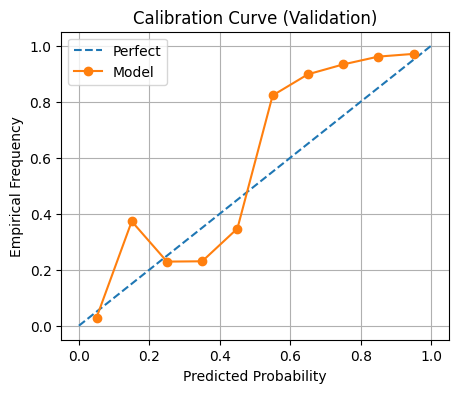

In [4]:
# ============================================================
# 2️⃣ LSTM FORECASTING — Time-Aware Split, Horizon = 1 Frame (Final)
# ============================================================
import os, numpy as np, torch, torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, brier_score_loss
import pandas as pd
import matplotlib.pyplot as plt

# --- Paths ---
DATA_PATH = r"C:\Project\Smart Parking\LocalMachine\Yolo\detections.csv"
MODEL_SAVE_PATH = r"C:\Project\Smart Parking\LocalMachine\Yolo\lstm_forecaster.pt"
assert os.path.exists(DATA_PATH), f"❌ detections.csv not found at {DATA_PATH}"

# ============================================================
# 📥 Load and prepare data
# ============================================================
data = pd.read_csv(DATA_PATH, parse_dates=["datetime"])
print(f"✅ Loaded {len(data)} detections from {data['camera'].nunique()} cameras, "
      f"{data['slot_id'].nunique()} slots.")

# --- Features and target ---
features = ["occupied", "hour", "dow"]
target_col = "occupied"
k = 5   # look-back window

# --- Normalize/scale numeric time features ---
data["hour"] = data["hour"] / 23.0
data["dow"]  = data["dow"] / 6.0

# ============================================================
# 🧩 Sequence Builder (per camera-slot, continuous by time)
# ============================================================
def make_seq(g, k):
    g = g.sort_values("datetime")
    arr = g[features].values
    times = g["datetime"].values
    X, Y, T = [], [], []
    for i in range(len(arr) - k):
        X.append(arr[i:i+k, :])
        Y.append(arr[i+k, 0])   # predict next occupancy
        T.append(times[i+k])
    return np.array(X, np.float32), np.array(Y, np.float32), np.array(T)

X_list, Y_list, T_list = [], [], []
for (cam, sid), g in data.groupby(["camera", "slot_id"]):
    if len(g) > k:
        x, y, t = make_seq(g, k)
        if len(x) > 0:
            X_list.append(x); Y_list.append(y); T_list.append(t)

if not X_list:
    raise RuntimeError("❌ No valid sequences built — check window size k or data continuity.")

X = np.concatenate(X_list)
Y = np.concatenate(Y_list)
T = np.concatenate(T_list)
print(f"📈 Total usable samples: {len(X)}")

# ============================================================
# 🕓 Time-aware split (last 20% for validation)
# ============================================================
order = np.argsort(T)
X, Y, T = X[order], Y[order], T[order]
cut = int(0.8 * len(X))
Xtr, Ytr = X[:cut], Y[:cut]
Xva, Yva = X[cut:], Y[cut:]
print(f"🧩 Train: {len(Xtr)}  |  Val: {len(Xva)}")

# ============================================================
# 🧠 Define LSTM Forecaster
# ============================================================
class LSTMForecaster(nn.Module):
    def __init__(self, inp=3, hid=64):
        super().__init__()
        self.lstm = nn.LSTM(inp, hid, batch_first=True)
        self.fc   = nn.Linear(hid, 1)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return torch.sigmoid(self.fc(h[-1]))

device = "cuda" if torch.cuda.is_available() else "cpu"
net = LSTMForecaster(inp=len(features), hid=64).to(device)
opt = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-5)
bce = nn.BCELoss()

# ============================================================
# ⚙️ Training Loop
# ============================================================
def run_epoch(X, Y, train=True, bs=256):
    net.train() if train else net.eval()
    tot = 0.0
    for i in range(0, len(X), bs):
        xb = torch.from_numpy(X[i:i+bs]).to(device)
        yb = torch.from_numpy(Y[i:i+bs]).unsqueeze(1).to(device)
        with torch.set_grad_enabled(train):
            p = net(xb)
            l = bce(p, yb)
            if train:
                opt.zero_grad(); l.backward(); opt.step()
        tot += l.item() * len(xb)
    return tot / max(1, len(X))

print("\n🚀 Training...")
for ep in range(15):
    trl = run_epoch(Xtr, Ytr, True)
    vl  = run_epoch(Xva, Yva, False)
    print(f"ep{ep+1:02d}: train {trl:.4f}  val {vl:.4f}")

# ============================================================
# 💾 Save Trained Model
# ============================================================
torch.save({
    "model_state_dict": net.state_dict(),
    "input_size": len(features),
    "hidden_size": 64,
    "window_size": k,
    "features": features
}, MODEL_SAVE_PATH)
print(f"\n💾 Model saved to: {MODEL_SAVE_PATH}")

# ============================================================
# 📊 Evaluation
# ============================================================
with torch.no_grad():
    P = net(torch.from_numpy(Xva).to(device)).cpu().numpy().ravel()
pred = (P > 0.5).astype(int)

print("\n📈 Validation Metrics")
print(f"Accuracy : {accuracy_score(Yva, pred):.4f}")
print(f"F1-score : {f1_score(Yva, pred):.4f}")
print(f"Brier    : {brier_score_loss(Yva, P):.4f}")

# ============================================================
# 📈 Calibration Curve
# ============================================================
bins = np.linspace(0, 1, 11)
binids = np.digitize(P, bins) - 1
centers, emp = [], []
for b in range(10):
    m = binids == b
    if m.sum() > 0:
        centers.append((bins[b] + bins[b+1]) / 2)
        emp.append(Yva[m].mean())

plt.figure(figsize=(5,4))
plt.plot([0,1],[0,1],'--',label="Perfect")
plt.plot(centers, emp,'o-',label="Model")
plt.xlabel("Predicted Probability")
plt.ylabel("Empirical Frequency")
plt.title("Calibration Curve (Validation)")
plt.legend(); plt.grid(True)
plt.show()


✅ YOLO model ready for Grad-CAM on cuda
🎯 Using conv layer: Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
🖼 Testing on: C:\Project\Smart Parking\LocalMachine\Yolo\dataset\FULL_IMAGE_1000x750\RAINY\2015-12-22\camera1\2015-12-22_0748.jpg


C:\Users\profe\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\module.py:1842: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


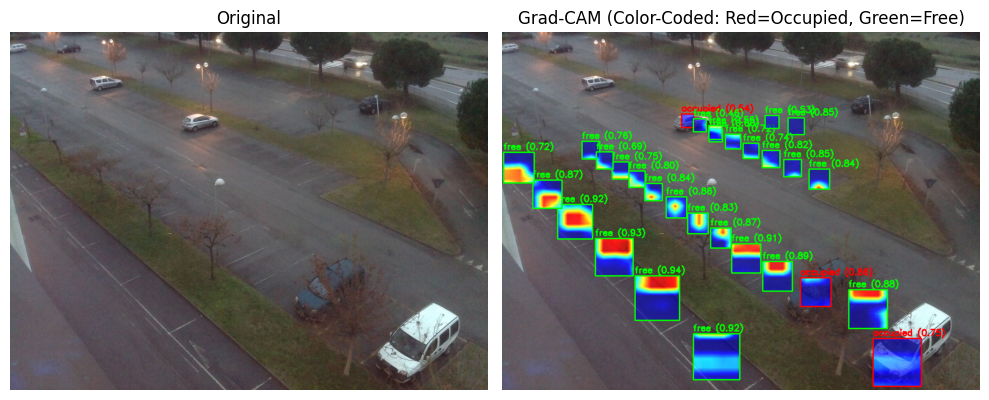

🧹 Hooks cleaned up.


In [5]:
# ============================================================
# 🧩 Shell 5 — YOLOv8 Grad-CAM (Per-Slot, Color-Coded)
# ============================================================
import os, glob, random, gc, cv2, torch, numpy as np, matplotlib.pyplot as plt
from ultralytics import YOLO

# ============================================================
# ⚙️ Setup
# ============================================================
IMAGE_ROOT = r"C:\Project\Smart Parking\LocalMachine\Yolo\dataset\FULL_IMAGE_1000x750"
MODEL_PATH = r"C:\Project\Smart Parking\LocalMachine\Yolo\Model\best.pt"

device = "cuda" if torch.cuda.is_available() else "cpu"
model = YOLO(MODEL_PATH)
torch_model = model.model.to(device).eval()

print(f"✅ YOLO model ready for Grad-CAM on {device}")

# ============================================================
# 🎯 Choose a good convolutional layer
# ============================================================
def find_good_conv2d(m):
    convs = [layer for _, layer in m.named_modules()
             if isinstance(layer, torch.nn.Conv2d) and layer.kernel_size != (1,1)]
    if len(convs) >= 3:
        return convs[-3]
    elif convs:
        return convs[-1]
    else:
        raise RuntimeError("❌ No Conv2d layer found for Grad-CAM.")
target_layer = find_good_conv2d(torch_model)
print(f"🎯 Using conv layer: {target_layer}")

# ============================================================
# 🪝 Hooks
# ============================================================
features, grads = {}, {}

def f_hook(_, __, out):  features["value"] = out
def b_hook(_, grad_in, grad_out): grads["value"] = grad_out[0]

handle_f = target_layer.register_forward_hook(f_hook)
handle_b = target_layer.register_backward_hook(b_hook)

# ============================================================
# 🧩 Letterbox (same as YOLO preprocessing)
# ============================================================
def letterbox(im, new_shape=(640,640), color=(114,114,114)):
    h, w = im.shape[:2]
    r = min(new_shape[0]/h, new_shape[1]/w)
    new_unpad = (int(round(w*r)), int(round(h*r)))
    dw, dh = new_shape[1]-new_unpad[0], new_shape[0]-new_unpad[1]
    dw, dh = dw//2, dh//2
    im_resized = cv2.resize(im, new_unpad, interpolation=cv2.INTER_LINEAR)
    im_padded = cv2.copyMakeBorder(im_resized, dh, dh, dw, dw,
                                   cv2.BORDER_CONSTANT, value=color)
    return im_padded, r, (dw, dh)

# ============================================================
# 🔥 Grad-CAM generator (per detection / slot)
# ============================================================
def gradcam_per_slot(img_bgr, conf_thresh=0.4):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]
    inp, r, (dw, dh) = letterbox(img_rgb)
    inp = inp.astype(np.float32)/255.0
    tensor = torch.from_numpy(inp).permute(2,0,1).unsqueeze(0).to(device)
    tensor.requires_grad_(True)

    # --- Standard detection first (no_grad) ---
    with torch.no_grad():
        dets = model.predict(source=img_rgb, conf=conf_thresh, verbose=False)[0]

    if len(dets.boxes) == 0:
        print("⚠️ No detections found in frame.")
        return img_bgr

    overlay = img_bgr.copy()
    boxes = dets.boxes.xyxy.cpu().numpy().astype(int)
    confs = dets.boxes.conf.cpu().numpy()
    clses = dets.boxes.cls.cpu().numpy().astype(int)

    # --- Per-detection Grad-CAM ---
    for (b, conf, clsid) in zip(boxes, confs, clses):
        x1, y1, x2, y2 = b
        cls_name = model.names.get(clsid, str(clsid)).lower()

        # choose color based on class
        if "occ" in cls_name or "car" in cls_name:
            color = (0, 0, 255)   # 🔴 occupied
        else:
            color = (0, 255, 0)   # 🟢 free

        torch_model.zero_grad(set_to_none=True)
        out = torch_model(tensor)[0]
        score = out.mean()
        score.backward(retain_graph=True)

        fmap = features["value"][0].detach().cpu()
        grad = grads["value"][0].detach().cpu()
        weights = grad.mean(dim=(1,2), keepdim=True)
        cam = torch.relu((weights * fmap).sum(0)).numpy()
        cam = cv2.resize(cam, (w, h))
        cam = (cam - cam.min()) / (cam.max() + 1e-8)

        # crop + overlay in slot region
        cam_crop = cam[y1:y2, x1:x2]
        heat = cv2.applyColorMap(np.uint8(255*cam_crop), cv2.COLORMAP_JET)
        roi = overlay[y1:y2, x1:x2]
        blended = cv2.addWeighted(roi, 0.4, heat, 0.9, 0)
        overlay[y1:y2, x1:x2] = blended

        # draw class label + color-coded box
        cv2.rectangle(overlay, (x1,y1), (x2,y2), color, 2)
        cv2.putText(overlay, f"{cls_name} ({conf:.2f})", (x1, y1-6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    torch.cuda.empty_cache(); gc.collect()
    return overlay

# ============================================================
# 🧪 Demo on random frame
# ============================================================
weather_dirs = [os.path.join(IMAGE_ROOT, w) for w in os.listdir(IMAGE_ROOT)]
rand_weather = random.choice(weather_dirs)
rand_date = random.choice(os.listdir(rand_weather))
rand_cam_dir = os.path.join(rand_weather, rand_date, "camera1")
sample_image = sorted(glob.glob(os.path.join(rand_cam_dir, "*.jpg")))[0]

print(f"🖼 Testing on: {sample_image}")
img = cv2.imread(sample_image)
cam_overlay = gradcam_per_slot(img, conf_thresh=0.4)

plt.figure(figsize=(10,7))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original"); plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(cam_overlay, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM (Color-Coded: Red=Occupied, Green=Free)"); plt.axis("off")
plt.tight_layout(); plt.show()

# cleanup hooks
handle_f.remove()
handle_b.remove()
print("🧹 Hooks cleaned up.")


Feature p_occ: sensitivity range 0.139 → 0.832
Feature hour: sensitivity range 0.702 → 0.213
Feature dow: sensitivity range 0.662 → 0.541


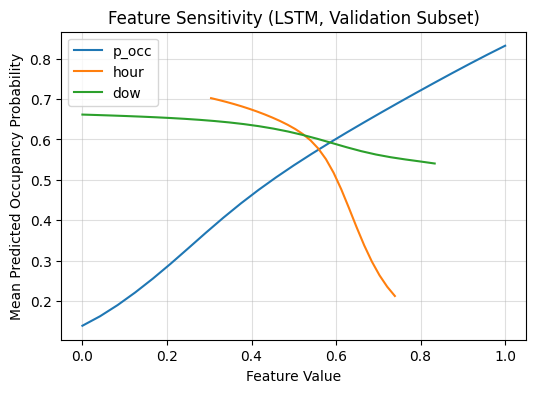

In [7]:
# ============================================================
# 🧭 Explainability (B2): Feature Sensitivity Curves
# ============================================================
import torch, numpy as np, matplotlib.pyplot as plt

# --- select random batch from validation set ---
idx = np.random.choice(len(Xva), size=512, replace=False)
Xref = Xva[idx].copy()
Yref = Yva[idx].copy()

feat_names = ["p_occ", "hour", "dow"]

# --- function to compute mean prediction for modified feature ---
def mean_pred(Xmod):
    with torch.no_grad():
        P = net(torch.from_numpy(Xmod).to(device)).cpu().numpy().ravel()
    return P.mean()

sens_results = {}

for j, name in enumerate(feat_names):
    base = Xref.copy()
    base_pred = mean_pred(base)
    values = np.linspace(Xref[:,:,j].min(), Xref[:,:,j].max(), 25)
    preds = []

    for v in values:
        Xm = base.copy()
        Xm[:,:,j] = v  # replace feature j with constant value v
        preds.append(mean_pred(Xm))

    sens_results[name] = (values, np.array(preds))
    print(f"Feature {name}: sensitivity range {preds[0]:.3f} → {preds[-1]:.3f}")

# --- plot sensitivity curves ---
plt.figure(figsize=(6,4))
for name, (vals, preds) in sens_results.items():
    plt.plot(vals, preds, label=name)
plt.xlabel("Feature Value")
plt.ylabel("Mean Predicted Occupancy Probability")
plt.title("Feature Sensitivity (LSTM, Validation Subset)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()


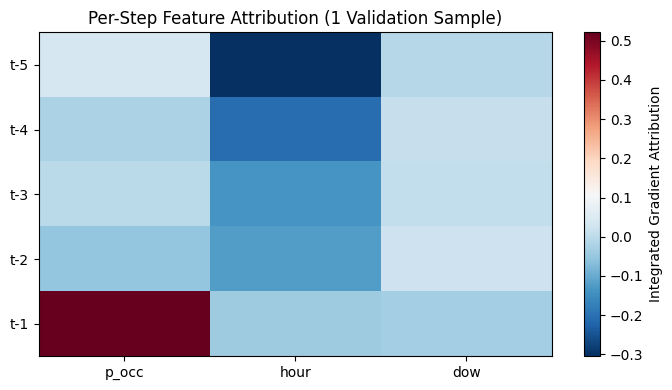

In [8]:
# ============================================================
# 🩻 Explainability (B2, Fixed): Integrated Gradients (LSTM-Safe)
# ============================================================
import torch, numpy as np, matplotlib.pyplot as plt
import os

# --- reload model if needed ---
MODEL_PATH = r"C:\Project\Smart Parking\LocalMachine\Yolo\lstm_forecaster.pt"
device = "cuda" if torch.cuda.is_available() else "cpu"

if 'net' not in locals():
    # quick reloader
    class LSTMForecaster(torch.nn.Module):
        def __init__(self, inp=3, hid=64):
            super().__init__()
            self.lstm = torch.nn.LSTM(inp, hid, batch_first=True)
            self.fc   = torch.nn.Linear(hid, 1)
        def forward(self, x):
            _, (h, _) = self.lstm(x)
            return torch.sigmoid(self.fc(h[-1]))

    ckpt = torch.load(MODEL_PATH, map_location=device)
    net = LSTMForecaster(inp=ckpt["input_size"], hid=ckpt["hidden_size"]).to(device)
    net.load_state_dict(ckpt["model_state_dict"])
    net.eval()
    print(f"✅ LSTM forecaster reloaded from {MODEL_PATH}")

# ============================================================
# ⚙️ Integrated Gradients Function
# ============================================================
def integrated_gradients(model, x, baseline=None, steps=50):
    """
    Compute Integrated Gradients for LSTM input x.
    Works safely with CuDNN by toggling model.train() during backward pass.
    """
    model.train()  # ✅ required for cudnn LSTM backward
    if baseline is None:
        baseline = torch.zeros_like(x)

    # Interpolation between baseline and input
    scaled_inputs = [baseline + (float(k)/steps) * (x - baseline) for k in range(steps+1)]

    grads = []
    for s_inp in scaled_inputs:
        s_inp = s_inp.clone().detach().requires_grad_(True)
        out = model(s_inp)          # forward
        out.sum().backward()        # backward for scalar output
        grads.append(s_inp.grad.detach().clone())
        model.zero_grad(set_to_none=True)

    grads = torch.stack(grads, dim=0)        # [steps+1, seq, feat]
    avg_grads = grads.mean(dim=0)            # [seq, feat]
    attr = (x - baseline) * avg_grads        # Integrated gradient attribution
    model.eval()
    return attr.detach()

# ============================================================
# 🎯 Run IG on one validation example
# ============================================================
assert 'Xva' in locals(), "❌ Xva not found. Please run forecasting cell first."

i = np.random.randint(len(Xva))
x_sample = torch.from_numpy(Xva[i:i+1]).to(device)

attr = integrated_gradients(net, x_sample, steps=40)
attr = attr.squeeze(0).cpu().numpy()   # [seq_len, num_features]

# ============================================================
# 🎨 Visualization
# ============================================================
plt.figure(figsize=(7, 4))
plt.imshow(attr, cmap="RdBu_r", aspect="auto")
plt.yticks(range(attr.shape[0]), [f"t-{k}" for k in range(attr.shape[0], 0, -1)])
plt.xticks(range(attr.shape[1]), ["p_occ", "hour", "dow"])
plt.colorbar(label="Integrated Gradient Attribution")
plt.title("Per-Step Feature Attribution (1 Validation Sample)")
plt.tight_layout()
plt.show()


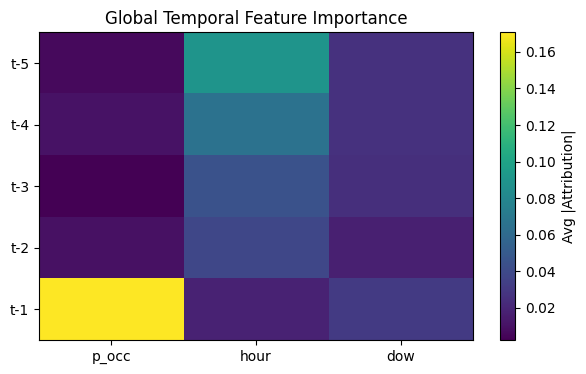

In [9]:
# Average absolute attribution over 200 validation samples
attrs = []
for i in np.random.choice(len(Xva), 200, replace=True):
    x_sample = torch.from_numpy(Xva[i:i+1]).to(device)
    a = integrated_gradients(net, x_sample).squeeze(0).abs().cpu().numpy()
    attrs.append(a)
avg_attr = np.mean(attrs, axis=0)

plt.figure(figsize=(7,4))
plt.imshow(avg_attr, cmap="viridis", aspect="auto")
plt.yticks(range(avg_attr.shape[0]), [f"t-{k}" for k in range(avg_attr.shape[0],0,-1)])
plt.xticks(range(avg_attr.shape[1]), ["p_occ","hour","dow"])
plt.colorbar(label="Avg |Attribution|")
plt.title("Global Temporal Feature Importance")
plt.show()


In [14]:
# ============================================================
# 🚗 Smart Parking Forecast + Explainability (YOLOv8 + LSTM + Grad-CAM)
#   • Local, robust, deterministic outputs
# ============================================================
import os, cv2, gc, json, glob, random, tempfile
import numpy as np
from tqdm import tqdm
from collections import defaultdict, deque
from ultralytics import YOLO
import torch
import pandas as pd

# ------------------- CONFIG -------------------
# Folders consistent with previous shells
BASE = r"C:\Project\Smart Parking\LocalMachine\Yolo"
MODEL_PATH_YOLO = os.path.join(BASE, "Model", "best.pt")
MODEL_PATH_LSTM = os.path.join(BASE, "lstm_forecaster.pt")
IMAGE_ROOT      = os.path.join(BASE, "dataset", "FULL_IMAGE_1000x750")
SLOT_META_DIR   = os.path.join(BASE, "dataset")   # cameraN.csv files
OUTPUT_DIR      = BASE

# Input video(s)
VIDEO_PATH = r"C:\Project\Smart Parking\Test Videos\parking_demo_long.mp4"
assert os.path.exists(VIDEO_PATH), f"❌ Input video not found: {VIDEO_PATH}"
assert os.path.exists(MODEL_PATH_YOLO), f"❌ YOLO model not found: {MODEL_PATH_YOLO}"

# Choose which camera's slot CSV to use for overlay/forecast
CAMERA_ID = "camera1"  # change to camera1..camera9 to match the video
SLOT_CSV  = os.path.join(SLOT_META_DIR, f"{CAMERA_ID}.csv")
assert os.path.exists(SLOT_CSV), f"❌ Slot CSV not found: {SLOT_CSV}"

# Frame size for which slot CSV is defined
ORIG_W, ORIG_H = 2592, 1944
IMG_W,  IMG_H  = 1000, 750

# LSTM window (must match training)
k = 5

# Thresholds
CONF_THRESH = 0.40
IOU_THRESH  = 0.30

# Optional: mapping for hour/dow per frame index (if you have a JSON mapping for multi-day video)
# If not provided, we fall back to neutral placeholders (12, 2)
HOUR_DOW_MAP_JSON = None  # r"C:\...\frame_time_map.json"
# ---------------------------------------------

# ---------------- DEVICE & MODELS ------------
device = "cuda" if torch.cuda.is_available() else "cpu"

# YOLO
yolo = YOLO(MODEL_PATH_YOLO)
print(f"✅ YOLO loaded on {yolo.device.type}")

# LSTM: load if 'net' not already present
if 'net' not in globals():
    class LSTMForecaster(torch.nn.Module):
        def __init__(self, inp=3, hid=64):
            super().__init__()
            self.lstm = torch.nn.LSTM(inp, hid, batch_first=True)
            self.fc   = torch.nn.Linear(hid, 1)
        def forward(self, x):
            _, (h, _) = self.lstm(x)
            return torch.sigmoid(self.fc(h[-1]))

    ckpt = torch.load(MODEL_PATH_LSTM, map_location=device)
    net = LSTMForecaster(inp=ckpt["input_size"], hid=ckpt["hidden_size"]).to(device)
    net.load_state_dict(ckpt["model_state_dict"])
    net.eval()
    print(f"✅ LSTM forecaster loaded from {MODEL_PATH_LSTM}")

# ----------------- HELPERS -------------------
def iou(a, b):
    # boxes as (x1,y1,x2,y2)
    xa, ya = max(a[0], b[0]), max(a[1], b[1])
    xb, yb = min(a[2], b[2]), min(a[3], b[3])
    iw, ih = max(0, xb - xa), max(0, yb - ya)
    inter = iw * ih
    areaA = max(0, (a[2]-a[0])) * max(0, (a[3]-a[1]))
    areaB = max(0, (b[2]-b[0])) * max(0, (b[3]-b[1]))
    union = areaA + areaB - inter + 1e-9
    return inter / union if union > 0 else 0.0

def is_occupied_label(label_str: str) -> bool:
    s = label_str.lower()
    return ("occ" in s) or ("car" in s)

def slot_p_occ(label, conf):
    # If your YOLO classes are 'occupied' and 'free', this works; if using a single 'car' class, treat presence as occupied
    return conf if is_occupied_label(label) else (1.0 - conf)

def predict_next(buf_deque):
    """Run LSTM forecast given rolling buffer of shape: [[p_occ, hour_norm, dow_norm], ...] length k."""
    if len(buf_deque) < k:
        return None, None
    x = np.array(buf_deque, dtype=np.float32).reshape(1, k, 3)
    with torch.no_grad():
        p_next = net(torch.from_numpy(x).to(device)).cpu().numpy().ravel()[0]
    cur_occ = 1 if buf_deque[-1][0] > 0.5 else 0
    p_change = (1 - p_next) if cur_occ == 1 else p_next
    return float(p_next), float(p_change)

# Load/scale slot boxes for chosen camera
slots_df = pd.read_csv(SLOT_CSV)
sx, sy = IMG_W / ORIG_W, IMG_H / ORIG_H
slots_df["x1"] = (slots_df["X"] * sx).astype(int)
slots_df["y1"] = (slots_df["Y"] * sy).astype(int)
slots_df["x2"] = ((slots_df["X"] + slots_df["W"]) * sx).astype(int)
slots_df["y2"] = ((slots_df["Y"] + slots_df["H"]) * sy).astype(int)
slot_boxes = {int(s.SlotId): (int(s.x1), int(s.y1), int(s.x2), int(s.y2)) for _, s in slots_df.iterrows()}

# Optional hour/dow map
frame_time_map = None
if HOUR_DOW_MAP_JSON and os.path.exists(HOUR_DOW_MAP_JSON):
    with open(HOUR_DOW_MAP_JSON, "r") as f:
        frame_time_map = json.load(f)  # expects {str(frame_idx): {"hour": int, "dow": int}}

# -------------- FORECAST VIDEO ----------------
# ============================================================
# 🎬 Forecast video generator (Clean Overlay Version)
# ============================================================
def make_forecast_video(video_path, frame_stride=1, conf_thresh=CONF_THRESH, iou_thresh=IOU_THRESH):
    cap = cv2.VideoCapture(video_path)
    assert cap.isOpened(), "⚠️ cannot open video"

    W, H = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps  = cap.get(cv2.CAP_PROP_FPS) or 25
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    out_path = os.path.join(OUTPUT_DIR, os.path.splitext(os.path.basename(video_path))[0] + "_forecast.mp4")
    out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*"mp4v"), fps / max(1, frame_stride), (W, H))

    buffers = defaultdict(lambda: deque(maxlen=k))
    print(f"🎞 Forecast: {total} frames @ {fps:.1f} fps → {out_path}")

    try:
        for fidx in tqdm(range(total), desc="YOLO + LSTM Forecast"):
            ret, frame = cap.read()
            if not ret:
                break
            if frame_stride > 1 and (fidx % frame_stride):
                continue

            # hour/dow normalization
            if frame_time_map and str(fidx) in frame_time_map:
                hour = frame_time_map[str(fidx)]["hour"]
                dow  = frame_time_map[str(fidx)]["dow"]
            else:
                hour, dow = 12, 2
            h_norm = hour / 23.0
            d_norm = dow  / 6.0

            res = yolo.predict(source=frame, conf=conf_thresh, verbose=False)[0]
            det_boxes = res.boxes.xyxy.cpu().numpy()
            det_confs = res.boxes.conf.cpu().numpy()
            det_cls   = res.boxes.cls.cpu().numpy().astype(int)

            for slot_id, sb in slot_boxes.items():
                x1, y1, x2, y2 = sb
                best_i, best_j = 0.0, -1
                for j, b in enumerate(det_boxes):
                    i = iou(sb, b)
                    if i > best_i:
                        best_i, best_j = i, j

                if best_i < iou_thresh or best_j == -1:
                    # draw grey for unmatched
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (128,128,128), 2)
                    continue

                cls_id = det_cls[best_j]
                label  = yolo.names.get(cls_id, str(cls_id))
                conf   = float(det_confs[best_j])
                p_occ  = slot_p_occ(label, conf)

                buffers[slot_id].append([p_occ, h_norm, d_norm])
                p_next, p_ch = predict_next(buffers[slot_id])

                # color coding
                color = (0,0,255) if p_occ >= 0.5 else (0,255,0)

                # draw box
                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

                # formatted display above the box
                text_y = max(20, y1 - 8)
                conf_text = f"{conf:.2f}"
                if p_next is not None:
                    # Δ symbol with change probability
                    delta_text = f"pc: {p_ch:.2f}"
                    display = f"{conf_text}   {delta_text}"
                else:
                    display = f"{conf_text}"

                # background rectangle for readability
                (tw, th), _ = cv2.getTextSize(display, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
                cv2.rectangle(frame, (x1, text_y - th - 4), (x1 + tw + 8, text_y + 4), (0,0,0), -1)
                cv2.putText(frame, display, (x1 + 4, text_y),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

            out.write(frame)

    finally:
        cap.release()
        out.release()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    print(f"✅ Forecast video saved: {out_path}")
    return out_path


# --------------- XAI (Grad-CAM) VIDEO ---------------
# We assume your previously-defined gradcam_per_slot(frame, conf_thresh) exists and
# draws heatmaps inside each detected region. We recolor boxes after to red/green.

def make_xai_video(video_path, frame_stride=1, conf_thresh=CONF_THRESH):
    cap = cv2.VideoCapture(video_path)
    assert cap.isOpened(), "⚠️ cannot open video"

    W, H = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps  = cap.get(cv2.CAP_PROP_FPS) or 25
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    out_path = os.path.join(OUTPUT_DIR, os.path.splitext(os.path.basename(video_path))[0] + "_xai.mp4")
    out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*"mp4v"), fps / max(1, frame_stride), (W, H))
    print(f"🎞 XAI: {total} frames @ {fps:.1f} fps → {out_path}")

    try:
        for idx in tqdm(range(total), desc="Grad-CAM frames"):
            ret, frame = cap.read()
            if not ret:
                break
            if frame_stride > 1 and (idx % frame_stride):
                continue

            # Produce Grad-CAM overlay (your function should not draw red/green boxes)
            heat = gradcam_per_slot(frame, conf_thresh=conf_thresh)

            # Re-run YOLO to draw red/green boxes + labels consistently
            res = yolo.predict(source=frame, conf=conf_thresh, verbose=False)[0]
            det_boxes = res.boxes.xyxy.cpu().numpy()
            det_cls   = res.boxes.cls.cpu().numpy().astype(int)
            det_confs = res.boxes.conf.cpu().numpy()

            for box, cls, conf in zip(det_boxes, det_cls, det_confs):
                x1, y1, x2, y2 = map(int, box)
                label = yolo.names.get(cls, str(cls)).lower()
                color = (0, 0, 255) if is_occupied_label(label) else (0, 255, 0)
                cv2.rectangle(heat, (x1, y1), (x2, y2), color, 2)
                cv2.putText(heat, f"{label} ({conf:.2f})", (x1, max(20, y1 - 6)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

            out.write(heat)

    finally:
        cap.release()
        out.release()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    print(f"✅ Grad-CAM video saved: {out_path}")
    return out_path

# -------------------- RUN --------------------
forecast_vid = make_forecast_video(VIDEO_PATH, frame_stride=1, conf_thresh=CONF_THRESH)
xai_vid      = make_xai_video(VIDEO_PATH, frame_stride=1, conf_thresh=CONF_THRESH)

print("\n✅ All done!")
print("Forecast video:", forecast_vid)
print("Grad-CAM video:", xai_vid)


✅ YOLO loaded on cpu
🎞 Forecast: 198 frames @ 5.0 fps → C:\Project\Smart Parking\LocalMachine\Yolo\parking_demo_long_forecast.mp4


YOLO + LSTM Forecast: 100%|██████████████████████████████████████████████████████████| 198/198 [00:17<00:00, 11.16it/s]


✅ Forecast video saved: C:\Project\Smart Parking\LocalMachine\Yolo\parking_demo_long_forecast.mp4
🎞 XAI: 198 frames @ 5.0 fps → C:\Project\Smart Parking\LocalMachine\Yolo\parking_demo_long_xai.mp4


Grad-CAM frames: 100%|███████████████████████████████████████████████████████████████| 198/198 [03:23<00:00,  1.03s/it]


✅ Grad-CAM video saved: C:\Project\Smart Parking\LocalMachine\Yolo\parking_demo_long_xai.mp4

✅ All done!
Forecast video: C:\Project\Smart Parking\LocalMachine\Yolo\parking_demo_long_forecast.mp4
Grad-CAM video: C:\Project\Smart Parking\LocalMachine\Yolo\parking_demo_long_xai.mp4
